In [1]:
import langchain
from typing import List,TypedDict
import time
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import START,END,StateGraph
from dotenv import load_dotenv
from langchain_community.document_loaders import




C:\Users\PC\AppData\Local\Temp\ipykernel_12080\1788875883.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [2]:
#docs=(PyPDFLoader("C:/Users/PC/Downloads/mit15_773_s24_lec03a.pdf").load()+
 #    PyPDFLoader("C:/Users/PC/Downloads/mit15_773_s24_lec04.pdf").load()+PyPDFLoader("C:/Users/PC/Downloads/mit15_773_s24_lec07.pdf").load())

In [37]:
#docs=PyPDFLoader("C:/Users/PC/OneDrive/Documents/Deep dive into DL.pdf").load()
loader=PyPDFLoader("C:/Users/PC/Downloads/Microsoft 2025 Annual Report.pdf")
docs=loader.load()
print(len(docs))

84


In [38]:
print(len(docs))

84


In [39]:
print(docs)

[Document(metadata={'producer': 'Skia/PDF m149', 'creator': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36', 'creationdate': '2026-07-05T15:47:19+00:00', 'title': 'Microsoft 2025 Annual Report', 'moddate': '2026-07-05T15:47:19+00:00', 'source': 'C:/Users/PC/Downloads/Microsoft 2025 Annual Report.pdf', 'total_pages': 84, 'page': 0, 'page_label': '1'}, page_content="Home\nShareholder Letter\nFinancial Review\nBusiness\nGeneral\nOperating Segments\nHuman Capital Resources\nOperations\nResearch & Development\nDistribution, Sales & Marketing\nLicensing Options\nGovernment Regulation\nAvailable Information\nDiscussion & Analysis\nMarket Risk\nIncome Statements\nBalance Sheets\nCash Flows Statements\nStockholders' Equity\nNotes\nAccounting Policies\nEarnings Per Share\nOther Income (Expense), Net\nInvestments\nDerivatives\nProperty and Equipment\nBusiness Combinations\nGoodwill\nIntangible Assets\nDebt\nIncome Taxes\nUnearned R

In [17]:
print(docs[0])

page_content='Lecture 3A 
Lightning Introduction to Keras/TF 
Training a DL Model for a Structured Data
Problem 
15.S04: Hands-on Deep Learning 
Spring 2024 
Farias, Ramakrishnan' metadata={'producer': 'macOS Version 14.2.1 (Build 23C71) Quartz PDFContext', 'creator': 'PyPDF', 'creationdate': '2024-02-12T17:54:58+00:00', 'author': 'Rama Ramakrishnan', 'moddate': '2025-09-08T16:40:55-04:00', 'title': '15.773 (S24): Lecture 03A: Lightning Introduction to Keras/TF; Training a DL Model for a Structured Data Problem', 'source': 'C:/Users/PC/Downloads/mit15_773_s24_lec03a.pdf', 'total_pages': 44, 'page': 0, 'page_label': '1'}


In [40]:
#chunking
from langchain_text_splitters import RecursiveCharacterTextSplitter
tex_spliter=RecursiveCharacterTextSplitter(chunk_size=100,chunk_overlap=10)
chunks=tex_spliter.split_documents(docs)

In [41]:
print(len(chunks
         ))

4032


In [42]:
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")
    

In [43]:
embedding=HuggingFaceEmbeddings(model_name='all-miniLM-L6-v2')

embedding

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(client=SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
), model_name='all-miniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, multi_process=False, show_progress=False)

In [44]:
# Filter out documents that have empty, whitespace-only, or None page_content
clean_docs = [
    doc for doc in docs 
    if doc.page_content and doc.page_content.strip()
]

# Now initialize your vectorstore safely
vectorstore = Chroma.from_documents(clean_docs, embedding)
#vectorstore=Chroma.from_documents(docs,embedding)

In [39]:
docs[0].page_content

'Lecture 3A \nLightning Introduction to Keras/TF \nTraining a DL Model for a Structured Data\nProblem \n15.S04: Hands-on Deep Learning \nSpring 2024 \nFarias, Ramakrishnan'

In [40]:
docs[0].page_content

'Lecture 3A \nLightning Introduction to Keras/TF \nTraining a DL Model for a Structured Data\nProblem \n15.S04: Hands-on Deep Learning \nSpring 2024 \nFarias, Ramakrishnan'

In [35]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# 1. Use the LangChain wrapper for your model
embedding_model = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')

# 2. Create the vector store
vectorstore = Chroma.from_documents(documents=docs, embedding=embedding_model,collection_name='my_colaction')

print("Successfully embedded and stored in Chroma!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

TypeError: TextEncodeInput must be Union[TextInputSequence, Tuple[InputSequence, InputSequence]]

In [47]:
vectorstore

In [73]:
retriver_vec=vectorstore.as_retriever()

In [120]:
#!pip install langchain-groq
import os
from langchain_groq import ChatGroq

# Groq ki free API key yahan dalein
os.environ["GROQ_API_KEY"] = "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" 

# ChatOpenAI ki jagah ise initialize karein (Baki aapka poora graph code same rahega
from langchain_groq import ChatGroq

# Purane model name ko badalkar 'llama-3.3-70b-versatile' kar dein
llm = ChatGroq(
    model="llama-3.3-70b-versatile", 
    temperature=0
)

In [121]:
class State(TypedDict):
    question: str
    docs:List[Document]
    ans:str

In [122]:
def retriver(state):
    q=state['question']
    return {'docs':retriver_vec.invoke(q)}

In [123]:
qury='microsoft ceo?'
result=retriver_vec.invoke(qury)
#print(result[0].page_content)
for i,doc in enumerate(result):
    print(f'result {i+1}...')
    print(doc.page_content)

result 1...
John W. Stanton 
Founder and Chairman, Trilogy
Partnerships
Teri L. List 
Former Executive Vice President and Chief Financial Officer, The Gap, Inc.
Penny S. Pritzker 
Founder and Chairman, PSP
Partners, LLC
Emma N. Walmsley 
Chief Executive Officer and Director,
GSK, plc
Board Committees
1. Audit Committee
2. Compensation Committee
3. Governance and Nominating Committee
4. Environmental, Social, and Public Policy Committee
EXECUTIVE OFFICERS
Satya Nadella
Chairman and Chief Executive Officer
Amy E. Hood
Executive Vice President and Chief Financial Officer
Judson B. Althoff
Executive Vice President and CEO Microsoft Commercial
Takeshi Numoto
Executive Vice President and Chief Marketing Officer
Amy L. Coleman
Executive Vice President and Chief Human Resources Officer
Bradford L. Smith
Vice Chair and President
Kathleen T. Hogan
Executive Vice President, Office of Strategy and
Transformation
Investor Relations
Investor Relations
1,4
1,3
4
2,4
Annual Report 2025
home  
05/07/20

In [124]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

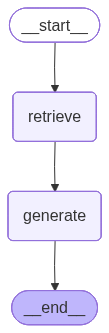

In [125]:
g = StateGraph(State)
g.add_node("retrieve", retriver)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [137]:
#res = app.invoke({'question':'microsoft'})
#for i, doc in enumerate(res):
 #  print(f'result {i+1}...')
   #print(doc[0].page_content)
#print(res)
res = app.invoke({"question":'who is founder of microsft?', "docs": [], "answer": ""})
print(res)


{'question': 'who is founder of microsft?', 'docs': [Document(metadata={'page': 81, 'creator': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36', 'total_pages': 84, 'producer': 'Skia/PDF m149', 'source': 'C:/Users/PC/Downloads/Microsoft 2025 Annual Report.pdf', 'creationdate': '2026-07-05T15:47:19+00:00', 'title': 'Microsoft 2025 Annual Report', 'page_label': '82', 'moddate': '2026-07-05T15:47:19+00:00'}, page_content='John W. Stanton \nFounder and Chairman, Trilogy\nPartnerships\nTeri L. List \nFormer Executive Vice President and Chief\xa0Financial Officer, The Gap, Inc.\nPenny S. Pritzker \nFounder and Chairman, PSP\nPartners, LLC\nEmma N. Walmsley \nChief Executive Officer and Director,\nGSK, plc\nBoard Committees\n1. Audit Committee\n2. Compensation Committee\n3. Governance and Nominating Committee\n4. Environmental, Social, and Public Policy Committee\nEXECUTIVE OFFICERS\nSatya Nadella\nChairman and Chief Executive Of

In [138]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

John W. Stanton 
Founder and Chairman, Trilogy
Partnerships
Teri L. List 
Former Executive Vice President and Chief Financial Officer, The Gap, Inc.
Penny S. Pritzker 
Founder and Chairman, PSP
Partners, LLC
Emma N. Walmsley 
Chief Executive Officer and Director,
GSK, plc
Board Committees
1. Audit Committee
2. Compensation Committee
3. Governance and Nominating Committee
4. Environmental, Social, and Public Policy Committee
EXECUTIVE OFFICERS
Satya Nadella
Chairman and Chief Executive Officer
Amy E. Hood
Executive Vice President and Chief Financial Officer
Judson B. Althoff
Executive Vice President and CEO Microsoft Commercial
Takeshi Numoto
Executive Vice President and Chief Marketing Officer
Amy L. Coleman
Executive Vice President and Chief Human Resources Officer
Bradford L. Smith
Vice Chair and President
Kathleen T. Hogan
Executive Vice President, Office of Strategy and
Transformation
Investor Relations
Investor Relations
1,4
1,3
4
2,4
Annual Report 2025
home  
05/07/2026, 21:17 Mi

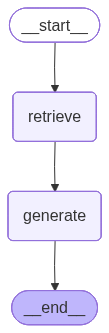

In [90]:
app

In [1]:
from langchain_experimental.text_splitter import SemanticChunker